# Lightweight SUMMA Model Runner (Decision + Parameter Sensitivity)

This notebook is a lightweight sandbox for quick model runs and sensitivity checks.

## What it does
- Uses one baseline setup and runs small scenario sets
- Supports model decision sensitivity with a dictionary of decision -> list of values
- Supports optional default parameter overrides
- Evaluates streamflow, ET, and snow against observations
- Plots aquifer diagnostics (scalarAquiferRecharge, scalarAquiferBaseflow)

## Notes
- Intended for fast iteration, not full calibration workflows
- Assumes forcing and project folders are already prepared
- Restores settings files after run loop so your base files are not left modified

In [3]:
import os
import sys
import shutil
from pathlib import Path
from itertools import product
from datetime import datetime

import numpy as np
import pandas as pd
import xarray as xr
import yaml
import matplotlib.pyplot as plt

# Change to CONFLUENCE repo root (adjust if needed)
os.chdir('/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro')
repo_root = Path.cwd()

# Local utilities used by EastBasinLumped and settings edits
from CONFLUENCE import CONFLUENCE
from utils.custom.adjust_settings import edit_modelDecisions, update_and_reformat_parameter_file, _format_parameter_value
from utils.custom.calc import empirical_lw_dilley_obrien


# Optional: leverage utility from seasonal ensemble experiment
modeling_dir = repo_root / 'ess-project' / 'modeling'
if str(modeling_dir) not in sys.path:
    sys.path.append(str(modeling_dir))

try:
    from seasonal_ensemble_experiment import _pct_change
except Exception:
    def _pct_change(baseline, member):
        if baseline is None or pd.isna(baseline) or abs(baseline) < 1e-15:
            return np.nan
        return ((member - baseline) / abs(baseline)) * 100.0

plt.style.use('default')
%matplotlib inline
print(f'Repo root: {repo_root}')

Repo root: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro


In [393]:
# ---------------------------------------------------------------------
# USER SETTINGS
# ---------------------------------------------------------------------
CONFIG_PATH = repo_root / 'ess-project' / '0_config_files' / 'config_East_River_lumped_bigBuckt.yaml'

# Simulation window for quick runs
SIM_START = '2010-10-01 00:00'
SIM_END = '2018-09-30 23:00'
EVAL_START = '2015-10-01'
EVAL_END = '2018-09-30'
SPINUP_PERIOD = '2010-10-01, 2014-09-30'

RUN_TAG = datetime.now().strftime('%Y%m%d_%H%M%S')
BASE_SCENARIO_NAME = 'base'

# Optional runtime config overrides (applied in-memory before runs).
# Use this to mirror EastBasinLumped-style config customization without editing
# the source YAML on disk.
CONFIG_UPDATES = {
    'EXPERIMENT_TIME_START': SIM_START,
    'EXPERIMENT_TIME_END': SIM_END,
    'EVALUATION_PERIOD': f'{EVAL_START}, {EVAL_END}',
    'SPINUP_PERIOD': SPINUP_PERIOD,
    # 'ROUTING_MODEL': 'mizuRoute',
    'USE_LINEAR_RESERVOIR_ROUTING': False,
    'LINEAR_RESERVOIR_K_FAST_DEFAULT': 0.039,
    'LINEAR_RESERVOIR_K_SLOW_DEFAULT': 0.054,
    'LINEAR_RESERVOIR_F_FAST_DEFAULT': 0.76
}

# Forcing source override (None -> auto-select from project forcing folders).
# Example: Path('/scratch/dlhogan/ess-project-data/domain_East_River_lumped/forcing/basin_averaged_data')
FORCING_SOURCE_DIR_OVERRIDE = None

# If True, patch source MetSim files in-place so SUMMA requirements are met
# (currently ensures data_step exists on source files, not just run-local copies).
NORMALIZE_SOURCE_METSIM_FILES_IN_PLACE = True

# Force-run forcing selection for this notebook run.
# If True, creates a run-local forcing folder filtered by month window and product tag
# and rewrites forcingFileList.txt to exactly those files.
USE_FILTERED_FORCING_FOR_RUN = True
# Override if needed (None -> use FORCING_PRODUCT_TAG from config).
FORCING_PRODUCT_TAG_OVERRIDE = 'metsim'
# If True, recompute LWRadAtm using Dilley-OBrien parameterization before each run
APPLY_DILLEY_OBRIEN_LW = True
# Save routed linear-reservoir series per scenario after evaluation.
# Files are written to: <lightweight_root>/derived/linear_reservoir_routed/
SAVE_LINEAR_RESERVOIR_ROUTED_SERIES = False
SAVE_LINEAR_RESERVOIR_ROUTED_NETCDF = False

# Safety: all settings edits happen in a run-local sandbox copy
USE_ISOLATED_SETTINGS_SANDBOX = True

# Initial condition file: change to 'warmState.nc' to start from a spun-up state
INIT_CONDITION_FILE = 'coldState.nc'

# ---- Model decision sweep -----------------------------------------------
# decision -> list of candidate values; first value is baseline
DECISION_SWEEP = {
    'groundwatr': ['bigBuckt'],
    'bcLowrSoiH': ['drainage'],
    # 'stomResist': ['BallBerry', 'Jarvis'],
    # 'astability': ['louisinv', 'mahrtexp'],
    # 'canopySrad': ['BeersLaw', 'CLM_2stream'],
    'hc_profile': ['constant'],
    'alb_method': ['varDecay'],
    'subRouting': ['qInstant'],
}


# Sweep mode: 'one_at_a_time' or 'full_factorial' (applies to both sweeps)
SWEEP_MODE = 'one_at_a_time'
USE_FIRST_VALUE_AS_BASELINE = True

# ---- Default parameter values (applied to every scenario) ---------------
LOCAL_PARAM_DEFAULTS = {
    "qSurfScale": 6.0,
    "aquiferBaseflowRate": 4e-7,
    "aquiferBaseflowExp": 1.5,
    "aquiferScaleFactor": 1.5,
    "k_macropore": 0.08,
    "k_soil": 3.01e-02,
    "theta_sat": 0.35,
    "albedoRefresh": 6.38,
    "albedoDecayRate": 5e5,
    "tempCritRain": 274.53,
}

BASIN_PARAM_DEFAULTS = {
    'routingGammaShape': 50,
    'routingGammaScale': 5.0e5,
}

# Observation files
STREAMFLOW_CSV_NAME = 'East_River_lumped_streamflow_processed.csv'
ET_CSV_NAME = 'openet_et_ensemble_East_monthly.csv'
SNOTEL_CSV_NAME = '380_Butte_sntl_obs.csv'

# Variables for aquifer diagnostics (strictly baseflow variables only; no runoff fallback)
AQ_RECHARGE_CANDIDATES = ['scalarAquiferRecharge']
AQ_BASEFLOW_CANDIDATES = ['scalarAquiferBaseflow', 'scalarSoilBaseflow']

print('Decision sweep keys:', list(DECISION_SWEEP.keys()))
print('Apply Dilley-OBrien longwave adjustment:', APPLY_DILLEY_OBRIEN_LW)
print('Sweep mode:', SWEEP_MODE)
print('Isolated settings sandbox:', USE_ISOLATED_SETTINGS_SANDBOX)
print('Initial condition file:', INIT_CONDITION_FILE)
print('Config updates:', CONFIG_UPDATES if CONFIG_UPDATES else 'none')
print('Use filtered forcing for run:', USE_FILTERED_FORCING_FOR_RUN)
print('Forcing product tag override:', FORCING_PRODUCT_TAG_OVERRIDE)
print('Forcing source override:', FORCING_SOURCE_DIR_OVERRIDE)
print('Normalize source MetSim files in place:', NORMALIZE_SOURCE_METSIM_FILES_IN_PLACE)
print('Save LR routed outputs:', SAVE_LINEAR_RESERVOIR_ROUTED_SERIES, SAVE_LINEAR_RESERVOIR_ROUTED_NETCDF)

Decision sweep keys: ['groundwatr', 'bcLowrSoiH', 'hc_profile', 'alb_method', 'subRouting']
Apply Dilley-OBrien longwave adjustment: True
Sweep mode: one_at_a_time
Isolated settings sandbox: True
Initial condition file: coldState.nc
Config updates: {'EXPERIMENT_TIME_START': '2010-10-01 00:00', 'EXPERIMENT_TIME_END': '2018-09-30 23:00', 'EVALUATION_PERIOD': '2015-10-01, 2018-09-30', 'SPINUP_PERIOD': '2010-10-01, 2014-09-30', 'USE_LINEAR_RESERVOIR_ROUTING': False, 'LINEAR_RESERVOIR_K_FAST_DEFAULT': 0.039, 'LINEAR_RESERVOIR_K_SLOW_DEFAULT': 0.054, 'LINEAR_RESERVOIR_F_FAST_DEFAULT': 0.76}
Use filtered forcing for run: True
Forcing product tag override: metsim
Forcing source override: None
Normalize source MetSim files in place: True
Save LR routed outputs: False False


In [394]:
# ---------------------------------------------------------------------
# HELPERS: settings edits, run setup, scenario definitions
# ---------------------------------------------------------------------
def load_config(path: Path) -> dict:
    with open(path, 'r') as f:
        return yaml.safe_load(f)


def project_paths(cfg: dict):
    data_dir = Path(cfg['CONFLUENCE_DATA_DIR'])
    domain_name = cfg['DOMAIN_NAME']
    project_dir = data_dir / f'domain_{domain_name}'
    settings_dir = project_dir / 'settings' / 'SUMMA'
    return project_dir, settings_dir


def _parse_parameter_file_values(file_path: Path) -> dict:
    values = {}
    with open(file_path, 'r') as f:
        for raw in f:
            line = raw.strip()
            if not line or line.startswith('!') or '|' not in raw:
                continue
            parts = raw.rstrip('\n').split('|')
            if len(parts) < 2:
                continue
            key = parts[0].strip()
            val_str = parts[1].strip().replace('d', 'e').replace('D', 'e')
            try:
                values[key] = float(val_str)
            except ValueError:
                continue
    return values


def _assert_and_report_parameter_updates(
    file_path: Path,
    updates: dict,
    label: str,
    rel_tol: float = 1e-6,
    abs_tol: float = 1e-12,
):
    current = _parse_parameter_file_values(file_path)
    missing = [k for k in updates if k not in current]
    if missing:
        raise KeyError(f'{label}: parameters not found in {file_path.name}: {missing}')

    mismatched = []
    for k, expected in updates.items():
        expected_f = float(expected)
        actual_f = float(current[k])
        if not np.isclose(actual_f, expected_f, rtol=rel_tol, atol=abs_tol):
            mismatched.append((k, actual_f, expected_f))

    if mismatched:
        msg = ', '.join([f"{k}: actual={a:.6g}, expected={e:.6g}" for k, a, e in mismatched])
        raise RuntimeError(f'{label}: parameter verification failed after update: {msg}')

    applied_preview = {k: current[k] for k in updates}
    print(f'{label}: applied {len(applied_preview)} parameters -> {applied_preview}')


def _apply_updates_with_fallback(file_path: Path, updates: dict, strict: bool = True) -> int:
    if not updates:
        return 0

    res = update_and_reformat_parameter_file(file_path, updates, reformat_all=True, verbose=False)
    updated_count = int(res.get('updated_count', 0)) if isinstance(res, dict) else 0
    if updated_count == len(updates):
        if strict:
            _assert_and_report_parameter_updates(file_path, updates, label=file_path.name)
        return updated_count

    # Fallback: syntax-preserving pipe-delimited replacement
    with open(file_path, 'r') as f:
        lines = f.readlines()

    new_lines = []
    n = 0
    for line in lines:
        stripped = line.strip()
        if not stripped or stripped.startswith('!') or '|' not in line:
            new_lines.append(line)
            continue

        parts = line.rstrip('\n').split('|')
        if len(parts) < 4:
            new_lines.append(line)
            continue

        key = parts[0].strip()
        if key in updates:
            parts[1] = f" {_format_parameter_value(updates[key])} "
            line = '|'.join(parts) + '\n'
            n += 1

        new_lines.append(line)

    if n > 0:
        with open(file_path, 'w') as f:
            f.writelines(new_lines)

    if strict:
        _assert_and_report_parameter_updates(file_path, updates, label=file_path.name)

    return n


def update_trial_params_nc(nc_path: Path, updates: dict) -> list:
    """Write parameter values from updates into trialParams.nc for any variable present in the file.

    Returns the list of parameter names that were updated.
    """
    if not nc_path.exists():
        print(f'  trialParams.nc not found at {nc_path}, skipping')
        return []

    with xr.open_dataset(nc_path) as ds_in:
        ds = ds_in.load()

    updated = []
    for name, value in updates.items():
        if name in ds.data_vars:
            ds[name].values[...] = float(value)
            updated.append(name)

    if updated:
        ds.to_netcdf(nc_path)
        print(f'  trialParams.nc: updated {updated}')
    ds.close()
    return updated


def _replace_line_value(line: str, key: str, value: str):
    if not line.strip().startswith(key):
        return line, False
    if "'" not in line:
        return f"{key:<20} '{value}'\n", True
    left = line[: line.find("'")]
    right = line[line.rfind("'") + 1 :]
    return f"{left}'{value}'{right}", True


def update_file_manager_for_run(
    file_manager: Path,
    sim_id: str,
    out_dir: Path,
    sim_start: str,
    sim_end: str,
    settings_path: Path = None,
    forcing_path: Path = None,
    init_condition_file: str = None,
):
    with open(file_manager, 'r') as f:
        lines = f.readlines()

    replacements = {
        'simStartTime': sim_start,
        'simEndTime': sim_end,
        'outFilePrefix': sim_id,
        'outputPath': str(out_dir) + '/',
    }
    if settings_path is not None:
        replacements['settingsPath'] = str(settings_path) + '/'
    if forcing_path is not None:
        replacements['forcingPath'] = str(forcing_path) + '/'
    if init_condition_file is not None:
        replacements['initConditionFile'] = init_condition_file

    new_lines = []
    seen = {k: False for k in replacements}

    for line in lines:
        updated = line
        for key, value in replacements.items():
            updated, changed = _replace_line_value(updated, key, value)
            if changed:
                seen[key] = True
                break
        new_lines.append(updated)

    missing = [k for k, found in seen.items() if not found]
    if missing:
        raise RuntimeError(f'Missing required keys in fileManager.txt: {missing}')

    with open(file_manager, 'w') as f:
        f.writelines(new_lines)


def _months_between(start_ts: pd.Timestamp, end_ts: pd.Timestamp):
    months = []
    cur = pd.Timestamp(start_ts.year, start_ts.month, 1)
    end_m = pd.Timestamp(end_ts.year, end_ts.month, 1)
    while cur <= end_m:
        months.append(cur.strftime('%Y%m'))
        cur = cur + pd.offsets.MonthBegin(1)
    return set(months)


def _extract_yyyymm_from_name(name: str):
    stem = Path(name).stem
    token = stem.split('_')[-1]
    return token if len(token) == 6 and token.isdigit() else None


def _matches_forcing_tag(name: str, tag: str | None) -> bool:
    if tag is None:
        return True
    tag_text = str(tag).strip().lower()
    if tag_text == '':
        return True
    name_l = name.lower()
    if tag_text == 'era5':
        return ('era5' in name_l) and ('metsim' not in name_l)
    return tag_text in name_l


def _ensure_summa_forcing_requirements(ds: xr.Dataset) -> tuple[xr.Dataset, bool]:
    """Ensure required SUMMA forcing fields/metadata are present.

    Current lightweight requirement: data_step variable must exist.
    """
    changed = False
    ds_out = ds

    if 'data_step' not in ds_out:
        if ds_out.sizes.get('time', 0) >= 2:
            dt_seconds = int(
                round(
                    (pd.Timestamp(ds_out['time'].values[1]) - pd.Timestamp(ds_out['time'].values[0])).total_seconds()
                )
            )
            dt_seconds = max(dt_seconds, 1)
        else:
            dt_seconds = 3600

        ds_out = ds_out.copy()
        ds_out['data_step'] = xr.DataArray(np.int32(dt_seconds))
        ds_out['data_step'].attrs['long_name'] = 'forcing time step size'
        ds_out['data_step'].attrs['units'] = 's'
        changed = True

    return ds_out, changed


def prepare_forcing_subset(
    source_forcing_dir: Path,
    target_forcing_dir: Path,
    target_forcing_list: Path,
    sim_start: str,
    sim_end: str,
    product_tag: str | None = None,
    recalc_longwave: bool = False,
):
    """Create a run-local forcing subset filtered by window and product tag.

    This avoids accidental mixed-product runs when source folders include both
    ERA5 and MetSim files.
    """
    target_forcing_dir.mkdir(parents=True, exist_ok=True)

    keep_months = _months_between(pd.Timestamp(sim_start), pd.Timestamp(sim_end))
    all_nc = sorted(source_forcing_dir.glob('*.nc'))
    selected = []
    for fp in all_nc:
        yyyymm = _extract_yyyymm_from_name(fp.name)
        if yyyymm is None or yyyymm not in keep_months:
            continue
        if not _matches_forcing_tag(fp.name, product_tag):
            continue
        selected.append(fp)

    if not selected:
        raise RuntimeError(
            f'No forcing files selected from {source_forcing_dir} for months {sorted(keep_months)} '
            f'with tag={product_tag!r}'
        )

    for src_file in selected:
        dst = target_forcing_dir / src_file.name
        shutil.copy2(src_file, dst)

        with xr.open_dataset(dst) as ds_in:
            ds = ds_in.load()

        changed = False
        ds, req_changed = _ensure_summa_forcing_requirements(ds)
        changed = changed or req_changed

        if recalc_longwave:
            ds['LWRadAtm'] = empirical_lw_dilley_obrien(ds['airtemp'], ds['airpres'], ds['spechum'])
            changed = True

        if changed:
            ds.to_netcdf(dst)
        ds.close()

    with open(target_forcing_list, 'w') as f:
        for fp in selected:
            f.write(f'{fp.name}\n')

    print(f'Prepared {len(selected)} forcing files from {source_forcing_dir}')
    print(f'  Product tag: {product_tag!r}')
    print(f'  First/last: {selected[0].name} ... {selected[-1].name}')
    return [fp.name for fp in selected]


def build_scenarios(decision_sweep: dict, mode: str = 'one_at_a_time', use_first_as_baseline: bool = True):
    scenarios = []

    if mode not in {'one_at_a_time', 'full_factorial'}:
        raise ValueError('mode must be one_at_a_time or full_factorial')

    baseline_decisions = {k: v[0] for k, v in decision_sweep.items() if v} if use_first_as_baseline else {}

    scenarios.append({'name': BASE_SCENARIO_NAME, 'decisions': baseline_decisions.copy()})

    if mode == 'one_at_a_time':
        for decision, values in decision_sweep.items():
            for i, value in enumerate(values):
                if use_first_as_baseline and i == 0:
                    continue
                trial = baseline_decisions.copy()
                trial[decision] = value
                scenarios.append({'name': f'{decision}__{value}', 'decisions': trial})

    elif mode == 'full_factorial':
        keys = list(decision_sweep.keys())
        for combo in product(*[decision_sweep[k] for k in keys]):
            decisions = dict(zip(keys, combo))
            if decisions == baseline_decisions:
                continue
            label = '__'.join([f'{k}-{v}' for k, v in decisions.items()])
            scenarios.append({'name': label, 'decisions': decisions})

    return scenarios

In [395]:
# ---------------------------------------------------------------------
# RUN SCENARIOS
# ---------------------------------------------------------------------
cfg = load_config(CONFIG_PATH)
if CONFIG_UPDATES:
    cfg.update(CONFIG_UPDATES)
    print('Applied CONFIG_UPDATES to runtime config:')
    for _k, _v in CONFIG_UPDATES.items():
        print(f'  {_k}: {_v}')
project_dir, source_settings_dir = project_paths(cfg)

# Create run-local workspace
lightweight_root = project_dir / 'simulations' / 'lightweight' / f'run_{RUN_TAG}'
lightweight_root.mkdir(parents=True, exist_ok=True)

if USE_ISOLATED_SETTINGS_SANDBOX:
    sandbox_settings_dir = lightweight_root / 'settings' / 'SUMMA'
    if sandbox_settings_dir.exists():
        shutil.rmtree(sandbox_settings_dir)
    shutil.copytree(source_settings_dir, sandbox_settings_dir)
    active_settings_dir = sandbox_settings_dir
else:
    active_settings_dir = source_settings_dir

print(f'Active settings dir: {active_settings_dir}')
if active_settings_dir == source_settings_dir:
    print('WARNING: using live project settings (USE_ISOLATED_SETTINGS_SANDBOX=False)')

# Build a temporary config that points CONFLUENCE to the active settings path
runtime_cfg = dict(cfg)
runtime_cfg['SETTINGS_SUMMA_PATH'] = str(active_settings_dir)
runtime_cfg['EXPERIMENT_ID'] = f'light_{RUN_TAG}_base'
runtime_cfg_path = lightweight_root / f'config_lightweight_{RUN_TAG}.yaml'
with open(runtime_cfg_path, 'w') as f:
    yaml.safe_dump(runtime_cfg, f, sort_keys=False)

model_decisions_file = active_settings_dir / 'modelDecisions.txt'
local_param_file     = active_settings_dir / 'localParamInfo.txt'
basin_param_file     = active_settings_dir / 'basinParamInfo.txt'
trial_params_nc      = active_settings_dir / 'trialParams.nc'
file_manager         = active_settings_dir / 'fileManager.txt'
forcing_list_file    = active_settings_dir / 'forcingFileList.txt'

if not all(p.exists() for p in [model_decisions_file, local_param_file, basin_param_file, file_manager, forcing_list_file]):
    raise FileNotFoundError('One or more required settings files are missing in active settings/SUMMA')

# Keep baseline copies inside sandbox for scenario resets
# trialParams.nc is also reset each scenario so parameters don't accumulate
model_decisions_base  = active_settings_dir / 'modelDecisions.base.txt'
local_params_base     = active_settings_dir / 'localParamInfo.base.txt'
basin_params_base     = active_settings_dir / 'basinParamInfo.base.txt'
trial_params_nc_base  = active_settings_dir / 'trialParams.base.nc'
for src, dst in [
    (model_decisions_file, model_decisions_base),
    (local_param_file,     local_params_base),
    (basin_param_file,     basin_params_base),
]:
    shutil.copy2(src, dst)
if trial_params_nc.exists():
    shutil.copy2(trial_params_nc, trial_params_nc_base)

# Collect all parameter overrides to push into trialParams.nc
all_param_overrides = {**LOCAL_PARAM_DEFAULTS, **BASIN_PARAM_DEFAULTS}

# Resolve forcing source directory: prefer basin_averaged_data for this notebook workflow
if FORCING_SOURCE_DIR_OVERRIDE is not None:
    source_forcing_path = Path(FORCING_SOURCE_DIR_OVERRIDE)
else:
    candidate_sources = [
        project_dir / 'forcing' / 'basin_averaged_data',
        project_dir / 'forcing' / 'SUMMA_input',
    ]
    source_forcing_path = next((p for p in candidate_sources if p.exists()), None)

if source_forcing_path is None or not source_forcing_path.exists():
    raise FileNotFoundError(
        'Could not resolve forcing source directory. Checked override and default candidates: '
        f"{project_dir / 'forcing' / 'basin_averaged_data'} and {project_dir / 'forcing' / 'SUMMA_input'}"
    )

active_forcing_path = source_forcing_path
print(f'Forcing source directory resolved to: {source_forcing_path}')

forcing_product_tag = FORCING_PRODUCT_TAG_OVERRIDE
if forcing_product_tag is None:
    forcing_product_tag = cfg.get('FORCING_PRODUCT_TAG', cfg.get('FORCING_DATASET', None))

# Optional source normalization so MetSim files themselves are SUMMA-ready.
if NORMALIZE_SOURCE_METSIM_FILES_IN_PLACE and str(forcing_product_tag).lower() == 'metsim':
    keep_months = _months_between(pd.Timestamp(SIM_START), pd.Timestamp(SIM_END))
    n_checked = 0
    n_fixed = 0
    for fp in sorted(source_forcing_path.glob('*.nc')):
        yyyymm = _extract_yyyymm_from_name(fp.name)
        if yyyymm is None or yyyymm not in keep_months:
            continue
        if not _matches_forcing_tag(fp.name, forcing_product_tag):
            continue

        with xr.open_dataset(fp) as ds_in:
            ds = ds_in.load()
        n_checked += 1

        ds_fixed, changed = _ensure_summa_forcing_requirements(ds)
        if changed:
            ds_fixed.to_netcdf(fp)
            n_fixed += 1
        ds_fixed.close()

    print(f'Normalized source forcing files checked={n_checked}, updated={n_fixed}')

if USE_FILTERED_FORCING_FOR_RUN or APPLY_DILLEY_OBRIEN_LW:
    filtered_forcing_dir = lightweight_root / 'forcing' / 'SUMMA_input_filtered'
    if filtered_forcing_dir.exists():
        shutil.rmtree(filtered_forcing_dir)

    selected_names = prepare_forcing_subset(
        source_forcing_dir=source_forcing_path,
        target_forcing_dir=filtered_forcing_dir,
        target_forcing_list=forcing_list_file,
        sim_start=SIM_START,
        sim_end=SIM_END,
        product_tag=forcing_product_tag if USE_FILTERED_FORCING_FOR_RUN else None,
        recalc_longwave=APPLY_DILLEY_OBRIEN_LW,
    )
    active_forcing_path = filtered_forcing_dir
    print(f'Using filtered forcing path: {active_forcing_path}')
    print(f'Selected forcing count: {len(selected_names)}')
    print(f'Forcing selection tag: {forcing_product_tag!r}')
else:
    print(f'Using source forcing path: {active_forcing_path}')

confluence = CONFLUENCE(str(runtime_cfg_path))
scenarios = build_scenarios(DECISION_SWEEP, mode=SWEEP_MODE, use_first_as_baseline=USE_FIRST_VALUE_AS_BASELINE)
print(f'Scenario count: {len(scenarios)}')

scenario_outputs = {}
run_errors = {}

for i, scn in enumerate(scenarios, start=1):
    scn_name = scn['name']
    sim_id = f'light_{RUN_TAG}_{scn_name}'.replace(' ', '_')
    out_dir = lightweight_root / 'results' / scn_name / 'SUMMA'
    out_dir.mkdir(parents=True, exist_ok=True)

    print(f'[{i}/{len(scenarios)}] Running {scn_name}')

    # Reset all mutable settings files to baseline
    shutil.copy2(model_decisions_base, model_decisions_file)
    shutil.copy2(local_params_base,    local_param_file)
    shutil.copy2(basin_params_base,    basin_param_file)
    if trial_params_nc_base.exists():
        shutil.copy2(trial_params_nc_base, trial_params_nc)

    # Apply shared parameter defaults to .txt files and trialParams.nc
    # (SUMMA uses trialParams.nc values when a variable is present there,
    #  ignoring the default in localParamInfo.txt)
    _apply_updates_with_fallback(local_param_file, LOCAL_PARAM_DEFAULTS, strict=True)
    _apply_updates_with_fallback(basin_param_file, BASIN_PARAM_DEFAULTS, strict=True)
    update_trial_params_nc(trial_params_nc, all_param_overrides)

    edit_modelDecisions(model_decisions_file, scn['decisions'])

    update_file_manager_for_run(
        file_manager=file_manager,
        sim_id=sim_id,
        out_dir=out_dir,
        sim_start=SIM_START,
        sim_end=SIM_END,
        settings_path=active_settings_dir,
        forcing_path=active_forcing_path,
        init_condition_file=INIT_CONDITION_FILE,
    )

    confluence.config['EXPERIMENT_ID'] = sim_id
    confluence.config['SETTINGS_SUMMA_PATH'] = str(active_settings_dir)
    confluence.config['EXPERIMENT_OUTPUT_SUMMA'] = str(out_dir)
    confluence.config['EXPERIMENT_LOG_SUMMA'] = str(out_dir / 'SUMMA_logs')

    try:
        confluence.managers['model'].run_models()
        nc_files = sorted(out_dir.glob('*_timestep.nc')) or sorted(out_dir.glob('*.nc'))
        if not nc_files:
            raise FileNotFoundError(f'No netcdf output found in {out_dir}')
        scenario_outputs[scn_name] = nc_files[-1]
    except Exception as e:
        run_errors[scn_name] = str(e)
        print(f'  FAILED: {scn_name} -> {e}')

print(f'Completed outputs: {len(scenario_outputs)}')
print(f'Lightweight workspace: {lightweight_root}')
if run_errors:
    print('Run errors:')
    for k, v in run_errors.items():
        print(f'  - {k}: {v}')

scenario_outputs

Applied CONFIG_UPDATES to runtime config:
  EXPERIMENT_TIME_START: 2010-10-01 00:00
  EXPERIMENT_TIME_END: 2018-09-30 23:00
  EVALUATION_PERIOD: 2015-10-01, 2018-09-30
  SPINUP_PERIOD: 2010-10-01, 2014-09-30
  USE_LINEAR_RESERVOIR_ROUTING: False
  LINEAR_RESERVOIR_K_FAST_DEFAULT: 0.039
  LINEAR_RESERVOIR_K_SLOW_DEFAULT: 0.054
  LINEAR_RESERVOIR_F_FAST_DEFAULT: 0.76
Active settings dir: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/lightweight/run_20260403_180716/settings/SUMMA
Forcing source directory resolved to: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/forcing/basin_averaged_data
Normalized source forcing files checked=96, updated=0
Prepared 96 forcing files from /scratch/dlhogan/ess-project-data/domain_East_River_lumped/forcing/basin_averaged_data
  Product tag: 'metsim'
  First/last: East_River_lumped_METSIM_remapped_metsim_201010.nc ... East_River_lumped_METSIM_remapped_metsim_201809.nc
Using filtered forcing path: /scratch/dlhogan/ess-pr

{'base': PosixPath('/scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/lightweight/run_20260403_180716/results/base/SUMMA/light_20260403_180716_base_timestep.nc')}

In [396]:
# ---------------------------------------------------------------------
# EVALUATION HELPERS (streamflow, ET, snow, aquifer diagnostics)
# ---------------------------------------------------------------------
def nse(obs: pd.Series, sim: pd.Series) -> float:
    valid = ~(obs.isna() | sim.isna())
    if valid.sum() < 2:
        return np.nan
    o = obs[valid].values
    s = sim[valid].values
    denom = np.sum((o - np.mean(o)) ** 2)
    if denom <= 0:
        return np.nan
    return 1.0 - np.sum((o - s) ** 2) / denom


def kge(obs: pd.Series, sim: pd.Series) -> float:
    valid = ~(obs.isna() | sim.isna())
    if valid.sum() < 2:
        return np.nan
    o = obs[valid]
    s = sim[valid]
    r = o.corr(s)
    alpha = s.std() / o.std() if o.std() > 0 else np.nan
    beta = s.mean() / o.mean() if abs(o.mean()) > 1e-12 else np.nan
    if pd.isna(r) or pd.isna(alpha) or pd.isna(beta):
        return np.nan
    return 1.0 - np.sqrt((r - 1.0) ** 2 + (alpha - 1.0) ** 2 + (beta - 1.0) ** 2)


def filter_snowmelt_months(s: pd.Series, months=(4, 5, 6, 7)) -> pd.Series:
    """Keep only rows whose month is in the given set."""
    return s[s.index.month.isin(months)]


def pick_var(ds: xr.Dataset, candidates):
    for c in candidates:
        if c in ds:
            return c
    return None


def _linear_reservoir_daily(q_in: np.ndarray, k: float) -> np.ndarray:
    q = np.asarray(q_in, dtype=float).ravel()
    q = np.nan_to_num(q, nan=0.0)
    k = float(np.clip(k, 1e-8, 0.999999))
    s = np.zeros_like(q, dtype=float)
    y = np.zeros_like(q, dtype=float)
    for i, qi in enumerate(q):
        prev = s[i - 1] if i > 0 else 0.0
        s[i] = (1.0 - k) * prev + qi
        y[i] = k * s[i]
    return np.maximum(y, 0.0)


def _two_linear_reservoir_daily(q_in: np.ndarray, k_fast: float, k_slow: float, f_fast: float) -> np.ndarray:
    f_fast = float(np.clip(f_fast, 0.0, 1.0))
    qf = _linear_reservoir_daily(f_fast * q_in, k_fast)
    qs = _linear_reservoir_daily((1.0 - f_fast) * q_in, k_slow)
    return qf + qs


def _resolve_lr_params_from_config_updates() -> tuple:
    k_fast = float(CONFIG_UPDATES.get('LINEAR_RESERVOIR_K_FAST_DEFAULT', 0.08))
    k_slow = float(CONFIG_UPDATES.get('LINEAR_RESERVOIR_K_SLOW_DEFAULT', 0.02))
    f_fast = float(
        CONFIG_UPDATES.get(
            'LINEAR_RESERVOIR_F_FAST_DEFAULT',
            CONFIG_UPDATES.get('LINEAR_RESERVOIR_FLOW_FRACTION_DEFAULT', 0.70),
        )
    )

    k_fast = float(np.clip(k_fast, 1e-8, 0.999999))
    k_slow = float(np.clip(k_slow, 1e-8, 0.999999))
    if k_slow >= k_fast:
        k_slow = max(1e-8, k_fast - 1e-6)
    f_fast = float(np.clip(f_fast, 0.0, 1.0))
    return k_fast, k_slow, f_fast


def streamflow_series(ds: xr.Dataset, basin_area_m2: float, freq: str = 'D', return_details: bool = False):
    details = {
        'used_linear_reservoir': False,
        'source_var': None,
        'streamflow_var': None,
        'k_fast': np.nan,
        'k_slow': np.nan,
        'f_fast': np.nan,
    }

    # Explicit linear-reservoir routing path for evaluation output.
    if CONFIG_UPDATES.get('USE_LINEAR_RESERVOIR_ROUTING', False) and 'scalarTotalRunoff' in ds:
        q = ds['scalarTotalRunoff'].squeeze()
        q_cms_daily = (q * basin_area_m2).to_pandas().resample('D').mean()
        k_fast, k_slow, f_fast = _resolve_lr_params_from_config_updates()
        routed = _two_linear_reservoir_daily(q_cms_daily.values, k_fast, k_slow, f_fast)
        s_daily = pd.Series(routed, index=q_cms_daily.index, name='linearReservoirRoutedRunoff')

        details.update({
            'used_linear_reservoir': True,
            'source_var': 'averageInstantRunoff',
            'streamflow_var': 'linearReservoirRoutedRunoff',
            'k_fast': k_fast,
            'k_slow': k_slow,
            'f_fast': f_fast,
        })
    else:
        # Default behavior: use routed SUMMA/mizuRoute variables when available.
        if 'scalarTotalRunoff' in ds:
            q = ds['scalarTotalRunoff'].squeeze()
            details['source_var'] = 'scalarTotalRunoff'
        elif 'scalarTotalRunoff' in ds:
            q = ds['scalarTotalRunoff'].squeeze()
            details['source_var'] = 'scalarTotalRunoff'
        elif 'averageInstantRunoff' in ds:
            q = ds['averageInstantRunoff'].squeeze()
            details['source_var'] = 'averageInstantRunoff'
        else:
            empty = pd.Series(dtype=float)
            return (empty, details) if return_details else empty

        s_daily = (q * basin_area_m2).to_pandas().resample('D').mean()
        details['streamflow_var'] = details['source_var']

    s = s_daily if freq == 'D' else s_daily.resample(freq).mean()
    return (s, details) if return_details else s


def et_monthly_mm(ds: xr.Dataset) -> pd.Series:
    # Prefer scalarTotalET if available (kg/m2/s = mm/s for water)
    if 'scalarTotalET' in ds:
        et_mm_s = ds['scalarTotalET'].squeeze()
        et_mm_day = -et_mm_s * 3600.0
        return et_mm_day.to_pandas().resample('MS').sum()

    # Fallback latent heat flux conversion (W/m2 -> mm/s)
    if 'scalarLatHeatTotal' in ds:
        lv = 2.45e6
        et_mm_s = ds['scalarLatHeatTotal'].squeeze() / lv
        et_mm_day = -et_mm_s * 3600.0
        return et_mm_day.to_pandas().resample('MS').sum()

    return pd.Series(dtype=float)


def swe_daily_mm(ds: xr.Dataset) -> pd.Series:
    if 'scalarSWE' not in ds:
        return pd.Series(dtype=float)
    return ds['scalarSWE'].squeeze().to_pandas().resample('D').mean()

In [397]:
# ---------------------------------------------------------------------
# LOAD OBSERVATIONS AND BASIN AREA
# ---------------------------------------------------------------------
# Basin area from attributes.nc (m2)
attrs_nc = project_dir / 'settings' / 'SUMMA' / 'attributes.nc'
with xr.open_dataset(attrs_nc) as _attrs:
    basin_area_m2 = float(_attrs['HRUarea'].sum())
print(f'Basin area: {basin_area_m2:.4e} m2')

# Observed streamflow (daily, m3/s)
obs_q_path = project_dir / 'observations' / 'streamflow' / 'preprocessed' / STREAMFLOW_CSV_NAME
if obs_q_path.exists():
    _qdf = pd.read_csv(obs_q_path, parse_dates=['datetime'])
    _qdf.set_index('datetime', inplace=True)
    obs_q = _qdf['discharge_cms'].resample('D').mean()
    print(f'Streamflow obs: {obs_q.index[0].date()} to {obs_q.index[-1].date()} ({obs_q.notna().sum()} valid days)')
else:
    obs_q = pd.Series(dtype=float)
    print(f'WARNING: streamflow CSV not found: {obs_q_path}')

# Observed ET (monthly, mm/month) from OpenET
obs_et_path = project_dir / 'observations' / 'et' / ET_CSV_NAME
if obs_et_path.exists():
    _etdf = pd.read_csv(obs_et_path, index_col=0, parse_dates=True)
    # Expect a single column or an 'et_mm' column; take the first numeric column
    _et_col = [c for c in _etdf.columns if _etdf[c].dtype.kind == 'f'][0]
    obs_et = _etdf[_et_col].resample('MS').mean()
    print(f'ET obs: {obs_et.index[0].date()} to {obs_et.index[-1].date()} ({obs_et.notna().sum()} valid months)')
else:
    obs_et = pd.Series(dtype=float)
    print(f'WARNING: ET CSV not found: {obs_et_path}')

# Observed SWE from SNOTEL (daily, mm)
obs_swe_path = project_dir / 'observations' / 'snow' / SNOTEL_CSV_NAME
if not obs_swe_path.exists():
    # also check under observations/ directly
    obs_swe_path = project_dir / 'observations' / SNOTEL_CSV_NAME
if obs_swe_path.exists():
    _swedf = pd.read_csv(obs_swe_path, parse_dates=True, index_col=0)
    _swe_col = [c for c in _swedf.columns if 'swe' in c.lower()]
    _swe_col = _swe_col[0] if _swe_col else _swedf.columns[0]
    obs_swe = _swedf[_swe_col].resample('D').mean() * 25.4
    obs_swe.index = obs_swe.index.tz_localize(None)
    print(f'SWE obs: {obs_swe.index[0].date()} to {obs_swe.index[-1].date()} ({obs_swe.notna().sum()} valid days)')
else:
    obs_swe = pd.Series(dtype=float)
    print(f'WARNING: SNOTEL CSV not found: {obs_swe_path}')

Basin area: 7.4825e+08 m2
Streamflow obs: 1999-10-01 to 2026-04-02 (9606 valid days)
ET obs: 2012-10-01 to 2022-09-01 (120 valid months)
SWE obs: 1980-10-01 to 2025-09-30 (16436 valid days)


In [398]:
# ---------------------------------------------------------------------
# METRIC TABLE ACROSS SCENARIOS
# Includes full-period AND Apr-Jul (snowmelt season) metrics separately
# ---------------------------------------------------------------------
SNOWMELT_MONTHS = (4, 5, 6, 7)
records = []
routed_lr_outputs = {}
scenario_streamflow_series = {}
timeslice_q = slice(pd.Timestamp(EVAL_START), pd.Timestamp(EVAL_END))
timeslice_m = slice(pd.Timestamp(EVAL_START).to_period('M').to_timestamp(), pd.Timestamp(EVAL_END).to_period('M').to_timestamp())

for scn, nc_path in scenario_outputs.items():
    ds = xr.open_dataset(nc_path)

    sim_q, q_details = streamflow_series(ds, basin_area_m2, return_details=True)
    sim_q = sim_q.loc[timeslice_q]
    scenario_streamflow_series[scn] = sim_q.copy()
    obs_q_i = obs_q.loc[timeslice_q]

    sim_et = et_monthly_mm(ds).loc[timeslice_m]
    obs_et_i = obs_et.loc[timeslice_m]

    sim_swe = swe_daily_mm(ds).loc[timeslice_q]
    obs_swe_i = obs_swe.loc[timeslice_q]

    # Keep routed LR series so it can be written to files after metrics are computed.
    if q_details.get('used_linear_reservoir', False):
        routed_lr_outputs[scn] = sim_q.copy()

    # Full-period streamflow metrics
    q_nse = nse(obs_q_i, sim_q)
    q_kge = kge(obs_q_i, sim_q)

    # Apr-Jul only streamflow metrics
    sim_q_sm = filter_snowmelt_months(sim_q, SNOWMELT_MONTHS)
    obs_q_sm = filter_snowmelt_months(obs_q_i, SNOWMELT_MONTHS)
    q_nse_sm = nse(obs_q_sm, sim_q_sm)
    q_kge_sm = kge(obs_q_sm, sim_q_sm)

    # Apr-Jul SWE metrics
    sim_swe_sm = filter_snowmelt_months(sim_swe, SNOWMELT_MONTHS)
    obs_swe_sm = filter_snowmelt_months(obs_swe_i, SNOWMELT_MONTHS)
    swe_rmse_sm = float(np.sqrt(((sim_swe_sm - obs_swe_sm) ** 2).mean())) if len(sim_swe_sm) else np.nan

    et_bias = float((sim_et - obs_et_i).mean()) if len(sim_et) else np.nan
    et_rmse = float(np.sqrt(((sim_et - obs_et_i) ** 2).mean())) if len(sim_et) else np.nan
    swe_rmse = float(np.sqrt(((sim_swe - obs_swe_i) ** 2).mean())) if len(sim_swe) else np.nan

    aq_recharge_name = pick_var(ds, AQ_RECHARGE_CANDIDATES)
    aq_baseflow_name = pick_var(ds, AQ_BASEFLOW_CANDIDATES)
    aq_recharge_mean = float(ds[aq_recharge_name].mean()) if aq_recharge_name else np.nan
    aq_baseflow_mean = float(ds[aq_baseflow_name].mean()) if aq_baseflow_name else np.nan

    records.append({
        'scenario': scn,
        'streamflow_var': q_details.get('streamflow_var'),
        'Q_NSE': q_nse,
        'Q_KGE': q_kge,
        'Q_NSE_AprJul': q_nse_sm,
        'Q_KGE_AprJul': q_kge_sm,
        'SWE_RMSE_AprJul': swe_rmse_sm,
        'ET_bias_mm_month': et_bias,
        'ET_RMSE_mm_month': et_rmse,
        'SWE_RMSE_mm_day': swe_rmse,
        'aq_recharge_var': aq_recharge_name,
        'aq_baseflow_var': aq_baseflow_name,
        'mean_scalarAquiferRecharge': aq_recharge_mean,
        'mean_scalarAquiferBaseflow': aq_baseflow_mean,
        'Q_source_var': q_details.get('source_var'),
        'Q_used_linear_reservoir': q_details.get('used_linear_reservoir', False),
        'LR_k_fast': q_details.get('k_fast', np.nan),
        'LR_k_slow': q_details.get('k_slow', np.nan),
        'LR_f_fast': q_details.get('f_fast', np.nan),
        'output_nc': str(nc_path),
    })

    ds.close()

metrics_df = pd.DataFrame(records).sort_values('Q_KGE_AprJul', ascending=False).reset_index(drop=True)
display(
    metrics_df[
        [
            'scenario', 'streamflow_var', 'Q_source_var', 'Q_used_linear_reservoir',
            'aq_baseflow_var',
            'Q_NSE', 'Q_KGE', 'Q_NSE_AprJul', 'Q_KGE_AprJul',
            'SWE_RMSE_AprJul', 'ET_bias_mm_month',
        ]
    ]
)

if BASE_SCENARIO_NAME in set(metrics_df['scenario']):
    base_row = metrics_df.loc[metrics_df['scenario'] == BASE_SCENARIO_NAME].iloc[0]
    metrics_df['dQ_KGE_AprJul_pct'] = metrics_df['Q_KGE_AprJul'].apply(lambda x: _pct_change(base_row['Q_KGE_AprJul'], x))
    display(metrics_df[['scenario', 'streamflow_var', 'aq_baseflow_var', 'Q_KGE', 'Q_KGE_AprJul', 'dQ_KGE_AprJul_pct']])

# Persist explicit routed LR outputs for traceability.
if routed_lr_outputs and SAVE_LINEAR_RESERVOIR_ROUTED_SERIES:
    routed_dir = lightweight_root / 'derived' / 'linear_reservoir_routed'
    routed_dir.mkdir(parents=True, exist_ok=True)

    for scn, s in routed_lr_outputs.items():
        safe_name = scn.replace(' ', '_').replace('/', '_')
        out_csv = routed_dir / f'{safe_name}_linear_reservoir_routed_daily_cms.csv'
        s.to_frame(name='linearReservoirRoutedRunoff').to_csv(out_csv, index_label='datetime')

        if SAVE_LINEAR_RESERVOIR_ROUTED_NETCDF:
            out_nc = routed_dir / f'{safe_name}_linear_reservoir_routed_daily_cms.nc'
            da = xr.DataArray(
                s.values,
                coords={'time': pd.to_datetime(s.index)},
                dims=['time'],
                name='linearReservoirRoutedRunoff',
            )
            da.attrs['units'] = 'm3 s-1'
            da.attrs['long_name'] = 'Two-linear-reservoir routed daily discharge'
            da.to_dataset().to_netcdf(out_nc)

    print(f'Saved linear-reservoir routed outputs for {len(routed_lr_outputs)} scenarios in: {routed_dir}')
elif CONFIG_UPDATES.get('USE_LINEAR_RESERVOIR_ROUTING', False):
    print('Linear reservoir routing is enabled, but no routed series were produced from available variables.')

,scenario,streamflow_var,Q_source_var,Q_used_linear_reservoir,aq_baseflow_var,Q_NSE,Q_KGE,Q_NSE_AprJul,Q_KGE_AprJul,SWE_RMSE_AprJul,ET_bias_mm_month
0,base,scalarTotalRunoff,scalarTotalRunoff,False,scalarAquiferBaseflow,0.373352,0.576689,0.144491,0.509577,98.778739,-32.964998


,scenario,streamflow_var,aq_baseflow_var,Q_KGE,Q_KGE_AprJul,dQ_KGE_AprJul_pct
0,base,scalarTotalRunoff,scalarAquiferBaseflow,0.576689,0.509577,0.0


/tmp/ipykernel_807741/2994208066.py:34: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(s.index, s.values, lw=1.5, alpha=0.85, label=scn)
/tmp/ipykernel_807741/2994208066.py:46: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(s.index, s.values, lw=1.5, alpha=0.85, label=scn)
/tmp/ipykernel_807741/2994208066.py:34: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(s.index, s.values, lw=1.5, alpha=0.85, label=scn)
/tmp/ipykernel_807741/2994208066.py:46: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(s.index, s.values, lw=1.5, alpha=0.85, label=scn)
/tmp/ipykernel_807741/2994208066.py:34: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(s.index, s.valu

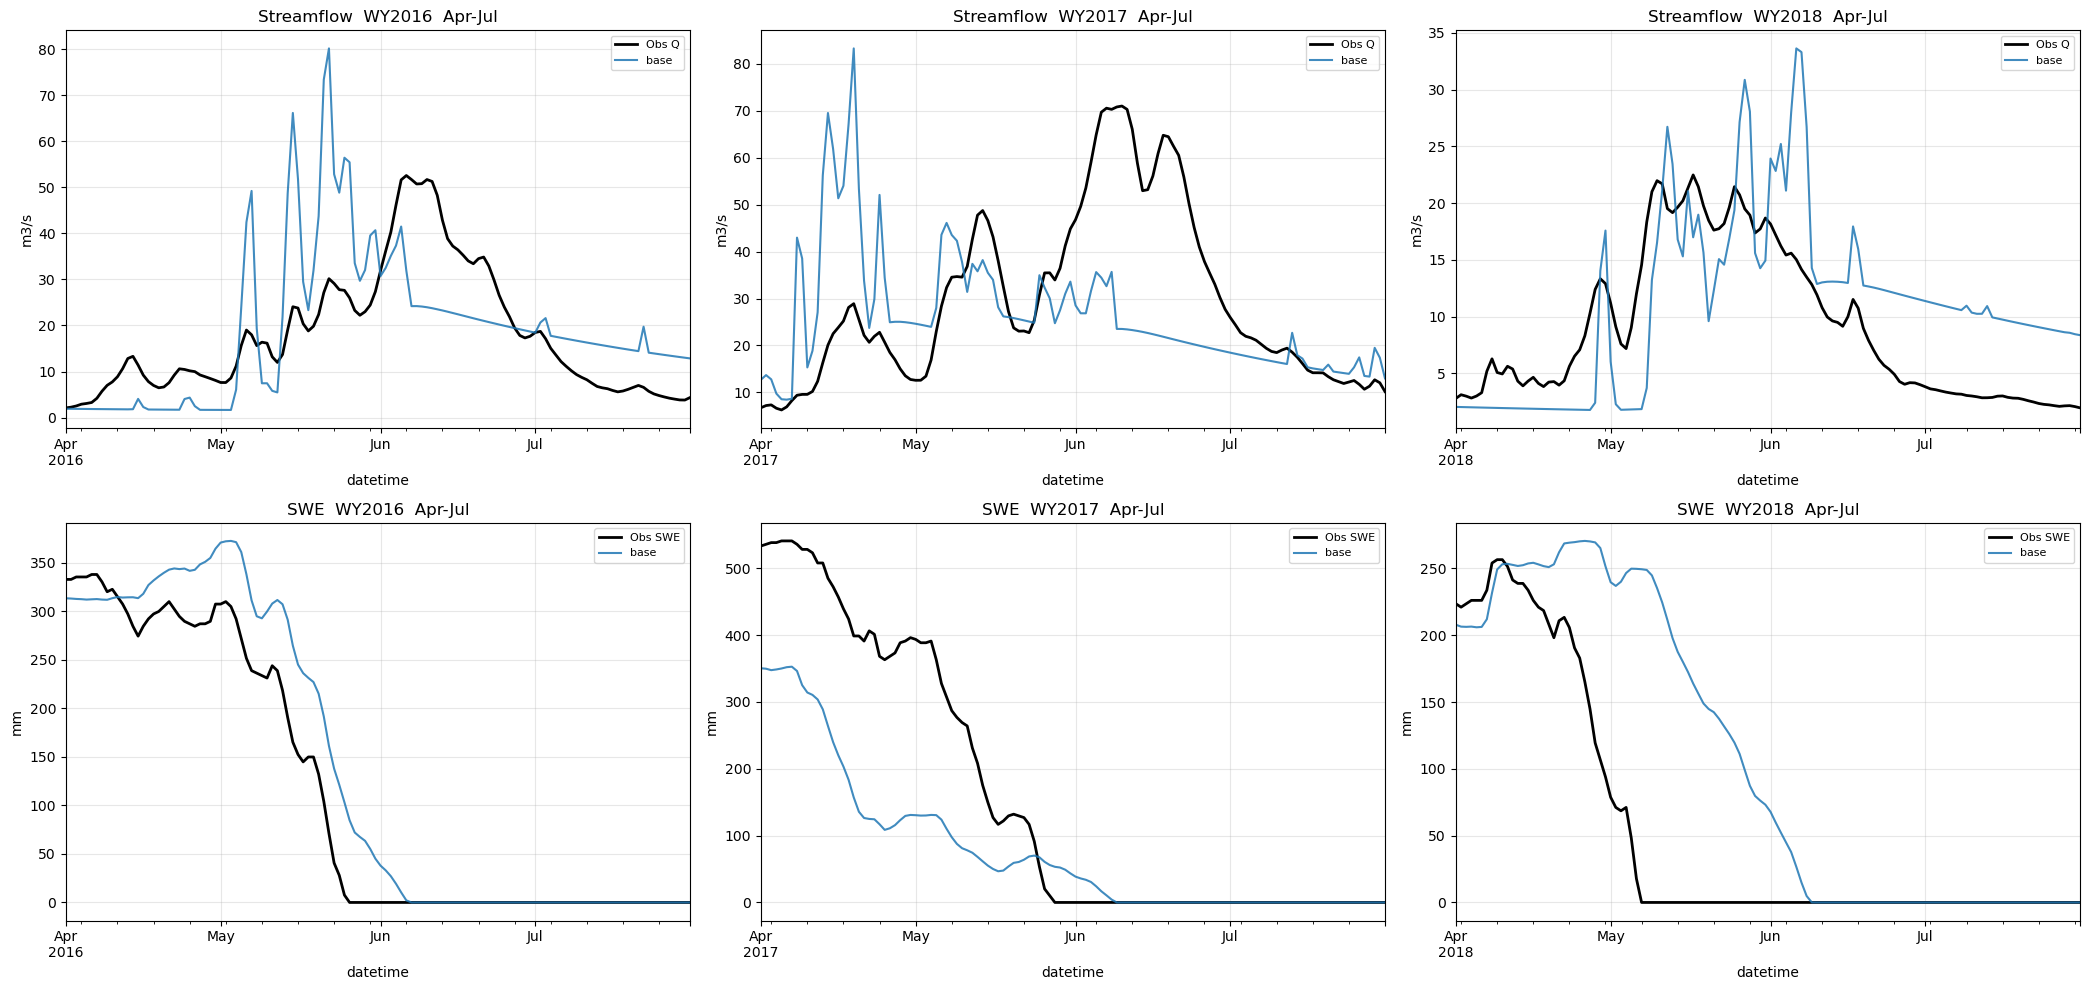

In [399]:
# ---------------------------------------------------------------------
# PLOT: Snowmelt season zoom (Apr-Jul) — one panel per water year
# ---------------------------------------------------------------------
if metrics_df.empty:
    raise RuntimeError('No scenario outputs available for plotting')

TOP_N = min(4, len(metrics_df))
plot_scenarios = metrics_df.head(TOP_N)['scenario'].tolist()
streamflow_cache = globals().get('scenario_streamflow_series', {})

# Find water years fully within the eval window that have Apr-Jul obs
eval_start_yr = pd.Timestamp(EVAL_START).year
eval_end_yr   = pd.Timestamp(EVAL_END).year
# Water year N = Oct(N-1) - Sep(N); plot Apr-Jul of water year N
water_years = [y for y in range(eval_start_yr + 1, eval_end_yr + 1)]

fig, axes = plt.subplots(2, len(water_years), figsize=(7 * len(water_years), 10), squeeze=False)

for col, wy in enumerate(water_years):
    apr_start = pd.Timestamp(f'{wy}-04-01')
    jul_end   = pd.Timestamp(f'{wy}-07-31')
    sl = slice(apr_start, jul_end)

    # Streamflow
    ax = axes[0][col]
    obs_q.loc[sl].plot(ax=ax, color='black', lw=2, label='Obs Q')
    for scn in plot_scenarios:
        s = streamflow_cache.get(scn, None)
        if s is None:
            ds = xr.open_dataset(scenario_outputs[scn])
            s = streamflow_series(ds, basin_area_m2).loc[timeslice_q]
            ds.close()
        s = s.loc[sl]
        ax.plot(s.index, s.values, lw=1.5, alpha=0.85, label=scn)
    ax.set_title(f'Streamflow  WY{wy}  Apr-Jul')
    ax.set_ylabel('m3/s')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    # SWE
    ax = axes[1][col]
    obs_swe.loc[sl].plot(ax=ax, color='black', lw=2, label='Obs SWE')
    for scn in plot_scenarios:
        ds = xr.open_dataset(scenario_outputs[scn])
        s = swe_daily_mm(ds).loc[sl]
        ax.plot(s.index, s.values, lw=1.5, alpha=0.85, label=scn)
        ds.close()
    ax.set_title(f'SWE  WY{wy}  Apr-Jul')
    ax.set_ylabel('mm')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [400]:
# Optional quick preview after running the plot setup cell
_plot_scenarios = globals().get('plot_scenarios', None)
if _plot_scenarios is None:
    print('plot_scenarios is not defined yet; run the plotting cell first.')
else:
    _plot_scenarios

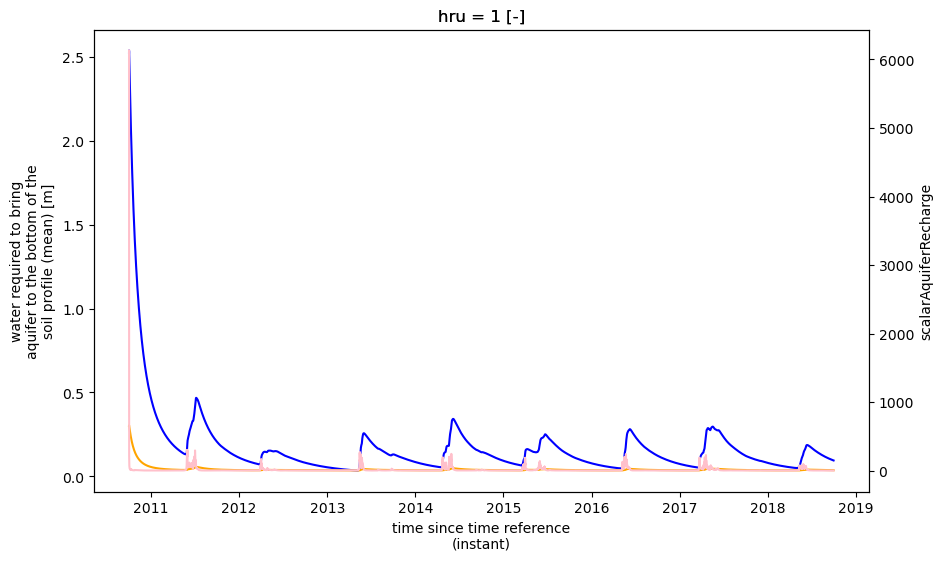

In [401]:
fig, ax = plt.subplots(figsize=(10, 6))
ds['scalarAquiferStorage_mean'].plot(ax=ax, color='blue', label='scalarAquiferStorage_mean')
ax2 = ax.twinx()
(ds['scalarAquiferBaseflow']*basin_area_m2).plot(ax=ax2, color='orange', label='scalarAquiferBaseflow')
(ds['scalarAquiferRecharge']*basin_area_m2).plot(ax=ax2, color='pink', label='scalarAquiferRecharge')
# ds['scalarInfiltration'].plot(ax=ax2, color='orange', label='scalarInfiltration')
# ds['scalarSoilBaseflow'].plot(ax=ax2, color='red', label='scalarSoilBaseflow')

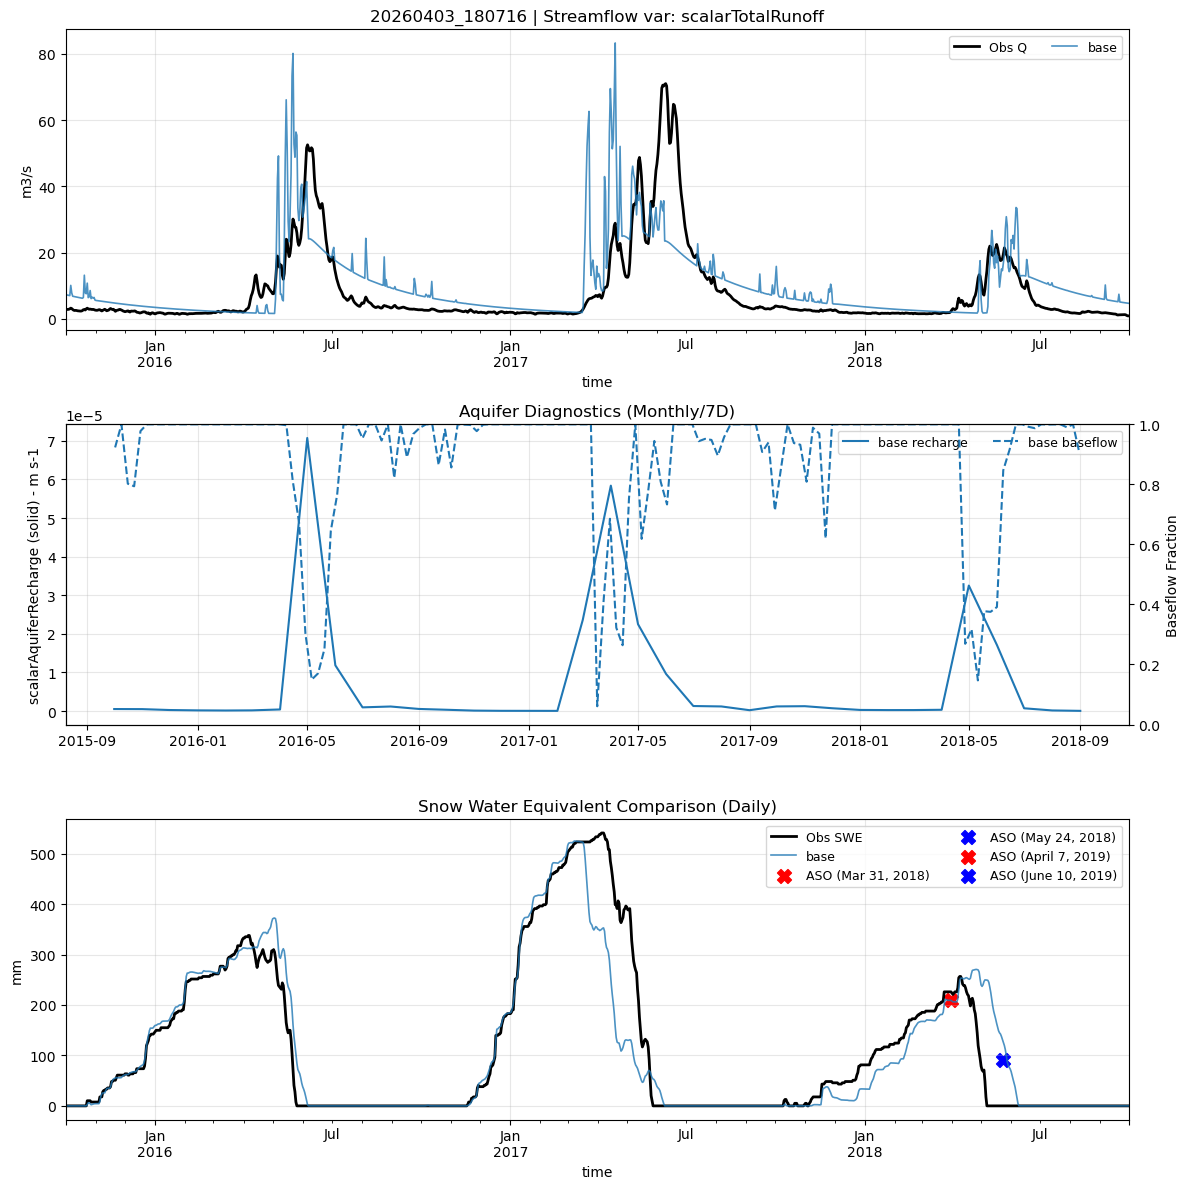

In [402]:
# ---------------------------------------------------------------------
# PLOTS: Streamflow, Aquifer diagnostics, Snow vs observations
# ---------------------------------------------------------------------
if metrics_df.empty:
    raise RuntimeError('No scenario outputs available for plotting')

# Plot top N scenarios by Q_KGE
TOP_N = min(4, len(metrics_df))
plot_scenarios = metrics_df.head(TOP_N)['scenario'].tolist()
streamflow_cache = globals().get('scenario_streamflow_series', {})

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=False)

# 1) Streamflow
ax = axes[0]
obs_q.loc[timeslice_q].plot(ax=ax, color='black', lw=2, label='Obs Q')
for scn in plot_scenarios:
    s = streamflow_cache.get(scn, None)
    if s is None:
        ds = xr.open_dataset(scenario_outputs[scn])
        s = streamflow_series(ds, basin_area_m2).loc[timeslice_q]
        ds.close()
    s.plot(ax=ax, lw=1.2, alpha=0.8, label=scn)
ax.set_title(f"{RUN_TAG} | Streamflow var: {metrics_df.loc[0, 'streamflow_var']}")
ax.set_ylabel('m3/s')
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=9)

# 2) Aquifer: recharge (left axis) and baseflow (right axis)
ax = axes[1]
ax2 = ax.twinx()
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
rech_unit = 'unknown units'
for ci, scn in enumerate(plot_scenarios):
    ds = xr.open_dataset(scenario_outputs[scn])

    color = colors[ci % len(colors)]
    rech_var = pick_var(ds, AQ_RECHARGE_CANDIDATES)
    base_var = pick_var(ds, AQ_BASEFLOW_CANDIDATES)
    stream_val = streamflow_cache.get(scn, None)
    if stream_val is None:
        stream_val = streamflow_series(ds, basin_area_m2, freq='7D')
    else:
        stream_val = stream_val.resample('7D').mean()
    stream_val = stream_val.loc[timeslice_m]

    if rech_var:
        rech_unit = ds[rech_var].attrs.get('units', 'unknown units')
        r = ds[rech_var].squeeze().to_pandas().resample('MS').sum().loc[timeslice_m]
        ax.plot(r.index, r.values, lw=1.5, color=color, label=f'{scn} recharge')

    if base_var:
        b = ds[base_var].squeeze().to_pandas().resample('7D').mean().loc[timeslice_m] * basin_area_m2
        q = ds["averageInstantRunoff"].squeeze().to_pandas().resample('7D').mean().loc[timeslice_m] * basin_area_m2
        common = b.index.intersection(q.index)
        frac = b.loc[common] / q.loc[common].replace(0, np.nan)
        ax2.plot(common, frac.values, lw=1.5, linestyle='--', color=color, label=f'{scn} baseflow')
        ax2.set_ylim(0, 1)
    else:
        print(f'WARNING: {scn} has no explicit baseflow variable in output (expected one of {AQ_BASEFLOW_CANDIDATES})')
    ds.close()
ax.set_title('Aquifer Diagnostics (Monthly/7D)')
ax.set_ylabel(f'scalarAquiferRecharge (solid) - {rech_unit}')
ax2.set_ylabel('Baseflow Fraction')
ax.grid(True, alpha=0.3)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
if lines1 or lines2:
    ax.legend(lines1 + lines2, labels1 + labels2, ncol=2, fontsize=9)

# 3) SWE (daily)
ax = axes[2]
obs_swe.loc[timeslice_q].plot(ax=ax, color='black', lw=2, label='Obs SWE')
for scn in plot_scenarios:
    ds = xr.open_dataset(scenario_outputs[scn])
    s = swe_daily_mm(ds).loc[timeslice_q]
    s.plot(ax=ax, lw=1.2, alpha=0.8, label=scn)
    ds.close()
# 210 mm on March 31, 2018
ax.scatter([pd.Timestamp('2018-03-31')], [210], color='red', marker='X', s=100, label='ASO (Mar 31, 2018)')
ax.scatter([pd.Timestamp('2018-05-24')], [90], color='blue', marker='X', s=100, label='ASO (May 24, 2018)')
ax.scatter([pd.Timestamp('2019-04-07')], [525], color='red', marker='X', s=100, label='ASO (April 7, 2019)')
ax.scatter([pd.Timestamp('2019-06-10')], [300], color='blue', marker='X', s=100, label='ASO (June 10, 2019)')
ax.set_title('Snow Water Equivalent Comparison (Daily)')
ax.set_ylabel('mm')
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.show()

/home/dlhogan/miniforge3/envs/ess-project-env/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


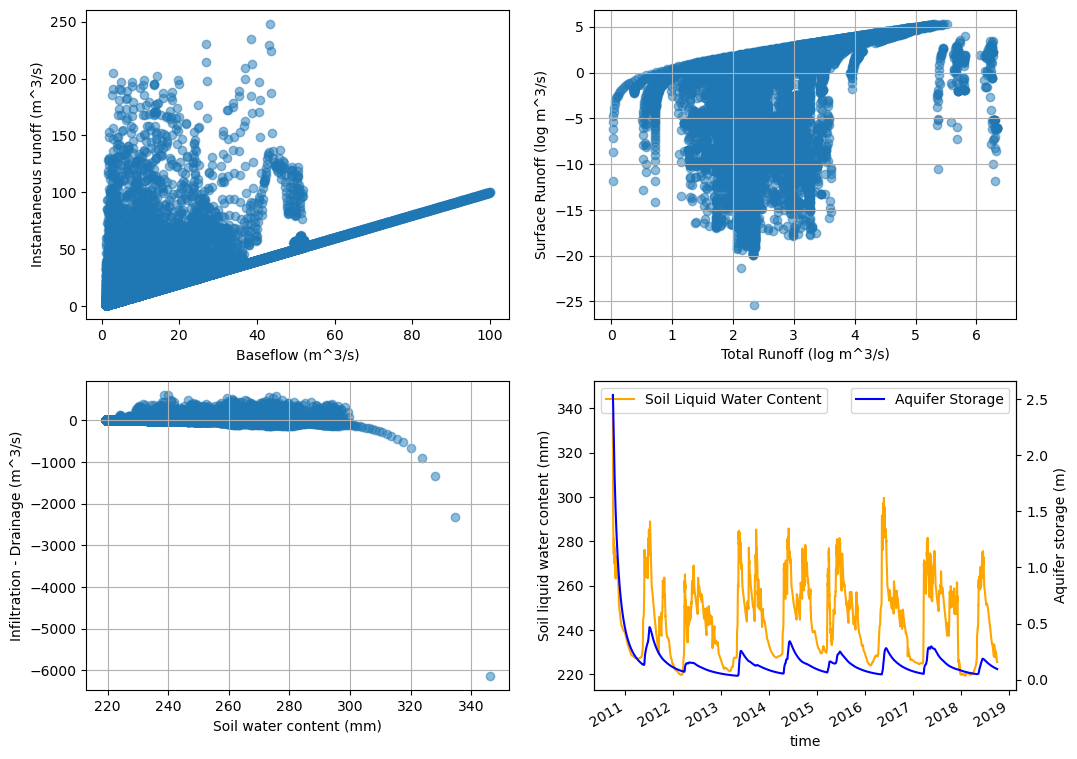

In [403]:
fig, axs = plt.subplots(2,2, figsize=(12,10))
axs = axs.flatten()
# scatter plots of baseflow vs q_inst
ax = axs[0]
routedRunoff = ds['scalarTotalRunoff'].squeeze().to_pandas() * basin_area_m2
baseflow = ds['scalarAquiferBaseflow'].squeeze().to_pandas() * basin_area_m2
ax.scatter(baseflow[baseflow<100], routedRunoff[baseflow<100], alpha=0.5)
ax.set_xlabel('Baseflow (m^3/s)')
ax.set_ylabel('Instantaneous runoff (m^3/s)')

# scatter plot of surface runoff vs total scalar runoff
ax = axs[1]
surface_runoff = ds['scalarSurfaceRunoff'].squeeze().to_pandas() * basin_area_m2
surface_runoff.index = pd.to_datetime(surface_runoff.index)
total_runoff = ds['scalarTotalRunoff'].squeeze().to_pandas()* basin_area_m2
total_runoff.index = pd.to_datetime(total_runoff.index)
ax.scatter(np.log(total_runoff), np.log(surface_runoff), alpha=0.5)
ax.set_xlabel('Total Runoff (log m^3/s)')
ax.set_ylabel('Surface Runoff (log m^3/s)')
# (surface_runoff/total_runoff).plot(ax=ax)
# ax.set_xlabel('Time')
# ax.set_ylabel('Surface Runoff Fraction')
ax.grid()

# relationship between surface runoff and infiltration
ax = axs[2]
infiltration = (ds['scalarInfiltration']-ds['scalarSoilDrainage']).squeeze().to_pandas() * basin_area_m2
infiltration.index = pd.to_datetime(infiltration.index)
soil_liq = ds['scalarTotalSoilLiq'].squeeze().to_pandas()
ax.scatter(soil_liq, infiltration, alpha=0.5)
ax.set_xlabel('Soil water content (mm)')
ax.set_ylabel('Infiltration - Drainage (m^3/s)')
# ax.set_xlim(surface_runoff.min(), surface_runoff.max())
# ax.set_ylim(surface_runoff.min(), surface_runoff.max())
ax.grid()

# relationship between aquifer recharge and soil drainage
ax = axs[3]
ax2 = ax.twinx()
aquifer_storage = ds['scalarAquiferStorage_mean'].squeeze().to_pandas()
aquifer_storage.index = pd.to_datetime(aquifer_storage.index)
soil_liq = ds['scalarTotalSoilLiq'].squeeze().to_pandas()
soil_liq.index = pd.to_datetime(soil_liq.index)
aquifer_storage.plot(ax=ax2, color='blue', label='Aquifer Storage')
soil_liq.plot(ax=ax, color='orange', label='Soil Liquid Water Content')
ax2.set_ylabel('Aquifer storage (m)')
ax.set_ylabel('Soil liquid water content (mm)')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')




## Quick Usage Checklist
1. Run imports and user settings cells
2. Edit DECISION_SWEEP and parameter defaults
3. Run scenario execution cell
4. Run metric and plot cells

For faster iteration, keep one_at_a_time mode and short simulation windows.

In [9]:
# Debug snapshot: why the run failed
print('RUN_TAG:', RUN_TAG)
print('lightweight_root:', lightweight_root)
print('active_forcing_path:', active_forcing_path)
print('forcing_list_file:', forcing_list_file)

print('\nrun_errors keys:', list(run_errors.keys()) if 'run_errors' in globals() else 'run_errors missing')
if 'run_errors' in globals() and run_errors:
    for k, v in run_errors.items():
        print(f'  {k}: {v}')
else:
    print('  no run_errors recorded')

print('\nscenario_outputs keys:', list(scenario_outputs.keys()) if 'scenario_outputs' in globals() else 'scenario_outputs missing')

if forcing_list_file.exists():
    lines = [ln.strip() for ln in forcing_list_file.read_text().splitlines() if ln.strip()]
    print(f'\nforcingFileList entries: {len(lines)}')
    if lines:
        print('  first:', lines[0])
        print('  last :', lines[-1])
        print('  sample:', lines[:5])
else:
    print('\nforcingFileList does not exist at expected path')

RUN_TAG: 20260326_230038
lightweight_root: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/lightweight/run_20260326_230038
active_forcing_path: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/lightweight/run_20260326_230038/forcing/SUMMA_input_filtered
forcing_list_file: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/lightweight/run_20260326_230038/settings/SUMMA/forcingFileList.txt

run_errors keys: ['base']
  base: Command '/home/dlhogan/bin/summa -m /scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/lightweight/run_20260326_230038/settings/SUMMA/fileManager.txt' returned non-zero exit status 1.

scenario_outputs keys: []

forcingFileList entries: 36
  first: East_River_lumped_metsim_201510.nc
  last : East_River_lumped_metsim_201809.nc
  sample: ['East_River_lumped_metsim_201510.nc', 'East_River_lumped_metsim_201511.nc', 'East_River_lumped_metsim_201512.nc', 'East_River_lumped_metsim_201601.nc'

In [ ]:
# Sanity check: build tiny filtered forcing subset and verify SUMMA requirements
from tempfile import mkdtemp

_tmp_root = Path(mkdtemp(prefix='forcing_check_'))
_tmp_forcing = _tmp_root / 'forcing'
_tmp_list = _tmp_root / 'forcingFileList.txt'

_source = Path('/scratch/dlhogan/ess-project-data/domain_East_River_lumped/forcing/basin_averaged_data')
_selected = prepare_forcing_subset(
    source_forcing_dir=_source,
    target_forcing_dir=_tmp_forcing,
    target_forcing_list=_tmp_list,
    sim_start='2015-10-01 00:00',
    sim_end='2015-10-31 23:00',
    product_tag='metsim',
    recalc_longwave=True,
)

print('selected:', _selected)
with xr.open_dataset(_tmp_forcing / _selected[0]) as _ds:
    print('data_step exists:', 'data_step' in _ds)
    print('data_step value:', _ds['data_step'].values if 'data_step' in _ds else None)

print('tmp forcing dir:', _tmp_forcing)
print('tmp forcing list:', _tmp_list)

Prepared 1 forcing files from /scratch/dlhogan/ess-project-data/domain_East_River_lumped/forcing/basin_averaged_data
  Product tag: 'metsim'
  First/last: East_River_lumped_metsim_201510.nc ... East_River_lumped_metsim_201510.nc
selected: ['East_River_lumped_metsim_201510.nc']
data_step exists: True
data_step value: 3600
tmp forcing dir: /tmp/forcing_check_m4lhyz1b/forcing
tmp forcing list: /tmp/forcing_check_m4lhyz1b/forcingFileList.txt
